# Maximum Likelihood Estimation for the Normal Distribution

## Learning Objectives
In this interactive notebook, you will:
1. Understand the Normal (Gaussian) distribution and its parameters

2. Visualize how different parameters affect the distribution shapeThe Normal distribution is one of the most important probability distributions in statistics and machine learning. Given observed data, Maximum Likelihood Estimation (MLE) provides a principled way to estimate the parameters ($\mu$ and $\sigma$) that best explain the data.

3. Learn the concept of likelihood and how to compute it for observed data## Introduction

4. Discover how to find Maximum Likelihood Estimates (MLE) for $\mu$ and $\sigma$

5. Compare numerical optimization with analytical solutions6. Understand why log-likelihood is preferred in practice

## 1. The Normal Distribution

$$\large f(x \mid \mu, \sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

where:
- $\mu$ is the **mean** (center/location of the distribution)
- $\sigma$ is the **standard deviation** (spread/scale of the distribution)
- $\sigma^2$ is the **variance**

## 2. Generate Synthetic Data

Let's generate some random data from a Normal distribution with known parameters. In practice, we observe the data and want to estimate the parameters that generated it.

In [8]:
# Import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import beta as beta_func
from ipywidgets import interact, FloatSlider, IntSlider
import warnings

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plot style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

def normal_distribution(x, mean, std_dev):
    """
    Calculates the normal distribution (PDF) for given x values, mean, and standard deviation.
    
    Parameters:
    -----------
    x : float or array-like
        The value(s) at which to evaluate the PDF
    mean : float
        The mean (μ) of the distribution
    std_dev : float
        The standard deviation (σ) of the distribution
    
    Returns:
    --------
    float or array-like
        The probability density at x
    """
    return (1 / (np.sqrt(2 * np.pi) * std_dev)) * np.exp(-0.5 * ((x - mean) / std_dev) ** 2)

print("✓ Libraries imported successfully!")
print("✓ Random seed set for reproducibility")

✓ Libraries imported successfully!
✓ Random seed set for reproducibility


Generated 50 samples from Normal(μ=10, σ=5)
Sample statistics: mean=8.87, std=4.62


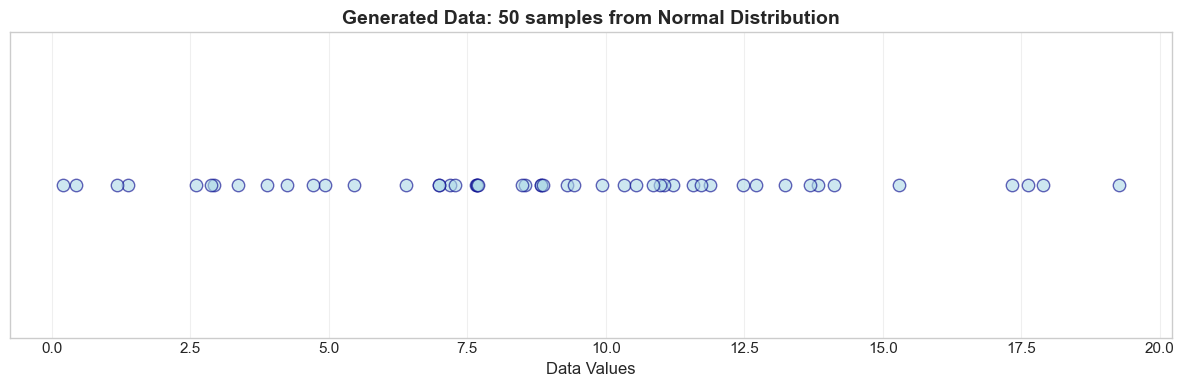

In [9]:
# Define the TRUE parameters (in real scenarios, these are unknown)
true_mean = 10
true_std_dev = 5

# Generate random data from the normal distribution
num_samples = 50
data = np.random.normal(true_mean, true_std_dev, num_samples)

print(f"Generated {num_samples} samples from Normal(μ={true_mean}, σ={true_std_dev})")
print(f"Sample statistics: mean={np.mean(data):.2f}, std={np.std(data):.2f}")

# Visualize the data
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(data, np.zeros_like(data), marker='o', s=80, alpha=0.6, edgecolors='darkblue', facecolors='lightblue')
ax.set_xlabel('Data Values', fontsize=12)
ax.set_ylabel('')
ax.set_yticks([])
ax.set_title(f'Generated Data: {num_samples} samples from Normal Distribution', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Which Mean Best Explains the Data?

The **likelihood** measures how probable the observed data is under different parameter values. Let's visualize how different choices of $\mu$ affect the fit to our data.

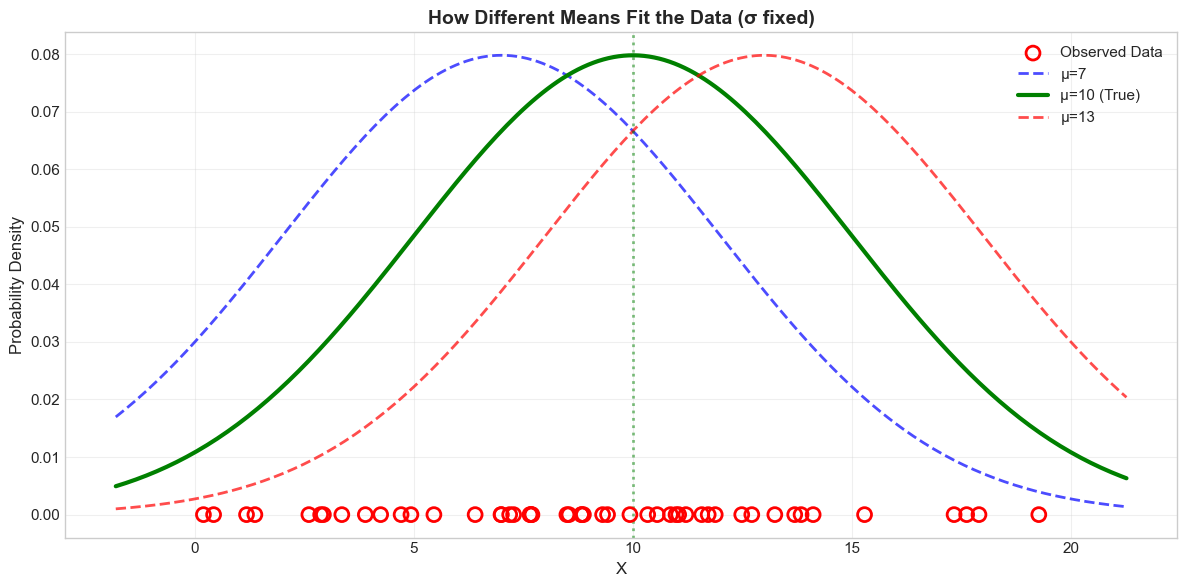

Interpretation: The green curve (μ=10) best aligns with the data points.


In [10]:
x = np.linspace(data.min() - 2, data.max() + 2, 200)

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(data, np.zeros_like(data), marker='o', s=100, facecolors='none', edgecolors='red', linewidth=2, label='Observed Data', zorder=5)
ax.plot(x, normal_distribution(x, true_mean - 3, true_std_dev), 'b--', lw=2, alpha=0.7, label=f'μ={true_mean-3}')
ax.plot(x, normal_distribution(x, true_mean, true_std_dev), 'g-', lw=3, label=f'μ={true_mean} (True)')
ax.plot(x, normal_distribution(x, true_mean + 3, true_std_dev), 'r--', lw=2, alpha=0.7, label=f'μ={true_mean+3}')

ax.axvline(true_mean, color='green', linestyle=':', alpha=0.5, lw=2)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('How Different Means Fit the Data (σ fixed)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation: The green curve (μ=10) best aligns with the data points.")

## 5. Interactive Exploration

Use the sliders below to see how changing $\mu$ and $\sigma$ affects the distribution shape!

In [11]:
def plot_interactive_normal(mu, sigma):
    """Interactive plot to explore how parameters affect the Normal distribution."""
    x_range = np.linspace(data.min() - 5, data.max() + 5, 200)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.scatter(data, np.zeros_like(data), marker='o', s=100, facecolors='none', 
               edgecolors='red', linewidth=2, label='Data', zorder=5)
    ax.plot(x_range, normal_distribution(x_range, mu, sigma), 'b-', lw=3, 
            label=f'Normal(μ={mu:.1f}, σ={sigma:.1f})')
    ax.axvline(mu, color='blue', linestyle='--', alpha=0.5, lw=2, label=f'μ={mu:.1f}')
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Probability Density', fontsize=12)
    ax.set_title('Interactive Normal Distribution', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 0.15)
    plt.tight_layout()
    plt.show()

# Create interactive widget
interact(plot_interactive_normal,
         mu=FloatSlider(value=true_mean, min=0, max=20, step=0.5, description='Mean (μ)'),
         sigma=FloatSlider(value=true_std_dev, min=1, max=10, step=0.5, description='Std Dev (σ)'));

interactive(children=(FloatSlider(value=10.0, description='Mean (μ)', max=20.0, step=0.5), FloatSlider(value=5…

## 4. Which Standard Deviation Best Explains the Data?

Similarly, let's see how different values of $\sigma$ (standard deviation) affect the fit when $\mu$ is fixed.

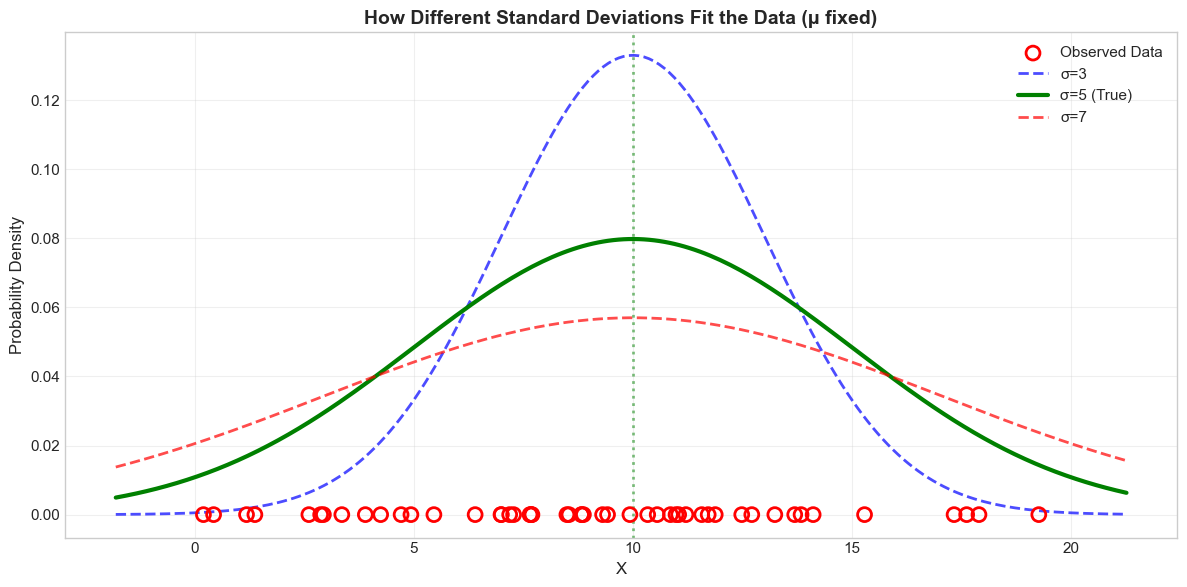

Interpretation: Smaller σ → taller/narrower curve. Larger σ → shorter/wider curve.
               The green curve (σ=5) provides the best balance.


In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(data, np.zeros_like(data), marker='o', s=100, facecolors='none', edgecolors='red', linewidth=2, label='Observed Data', zorder=5)
ax.plot(x, normal_distribution(x, true_mean, true_std_dev - 2), 'b--', lw=2, alpha=0.7, label=f'σ={true_std_dev-2}')
ax.plot(x, normal_distribution(x, true_mean, true_std_dev), 'g-', lw=3, label=f'σ={true_std_dev} (True)')
ax.plot(x, normal_distribution(x, true_mean, true_std_dev + 2), 'r--', lw=2, alpha=0.7, label=f'σ={true_std_dev+2}')
ax.axvline(true_mean, color='green', linestyle=':', alpha=0.5, lw=2)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('How Different Standard Deviations Fit the Data (μ fixed)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation: Smaller σ → taller/narrower curve. Larger σ → shorter/wider curve.")
print("               The green curve (σ=5) provides the best balance.")

## 6. Likelihood of Just One Data Point Given $\mu, \sigma$

$$\large  L(\mu,\sigma | x_1)= \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_1-\mu)^2}{2\sigma^2}\right)$$

Try what happens to the curve when you change the values of $\mu$ and $\sigma$ and the data point $x_1$

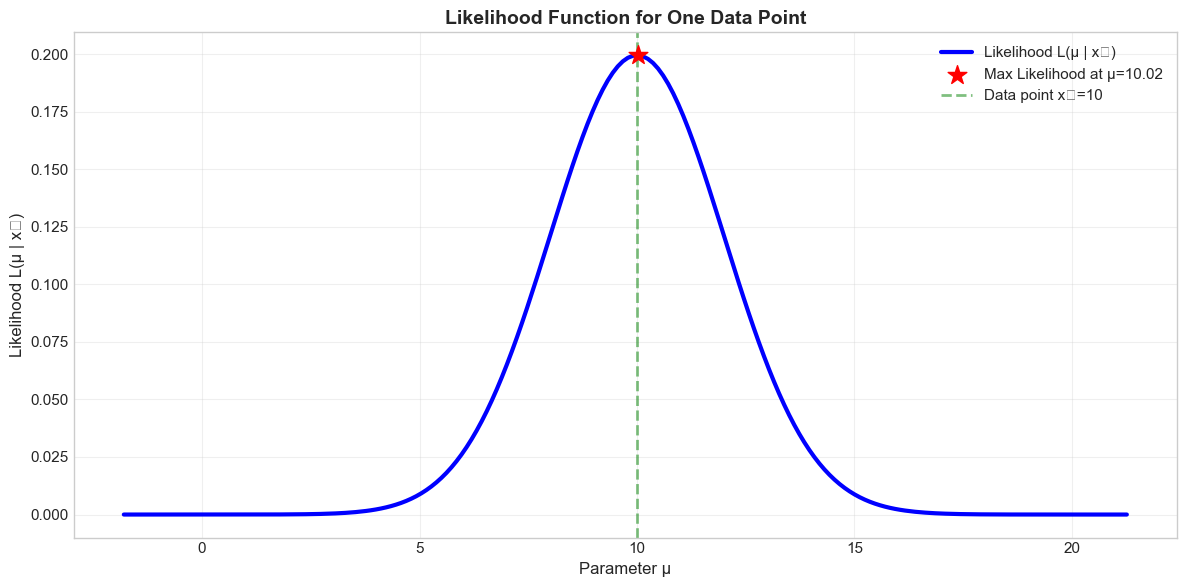

The most likely μ that explains x₁=10 is μ̂=10.02


In [13]:
mu_range = np.linspace(data.min() - 2, data.max() + 2, 200)
sigma = 2
x1 = 10

# Vectorized computation (much faster than loop!)
L = normal_distribution(x1, mu_range, sigma)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(mu_range, L, 'b-', lw=3, label='Likelihood L(μ | x₁)')
max_idx = np.argmax(L)
ax.scatter(mu_range[max_idx], L[max_idx], color='red', s=200, zorder=5, 
           label=f'Max Likelihood at μ={mu_range[max_idx]:.2f}', marker='*')
ax.axvline(x1, color='green', linestyle='--', alpha=0.5, lw=2, label=f'Data point x₁={x1}')
ax.set_xlabel('Parameter μ', fontsize=12)
ax.set_ylabel('Likelihood L(μ | x₁)', fontsize=12)
ax.set_title('Likelihood Function for One Data Point', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The most likely μ that explains x₁={x1} is μ̂={mu_range[max_idx]:.2f}")

## 7. Likelihood of Two Data Points Given $\mu, \sigma$

$$\large  L(\mu,\sigma | x_1,x_2)= \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_1-\mu)^2}{2\sigma^2}\right) \times \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_2-\mu)^2}{2\sigma^2}\right)$$

Try what happens to the curve when you change the values of $\mu$ and $\sigma$ and the data point $x_1,x_2$

Assume that both the measures are independent

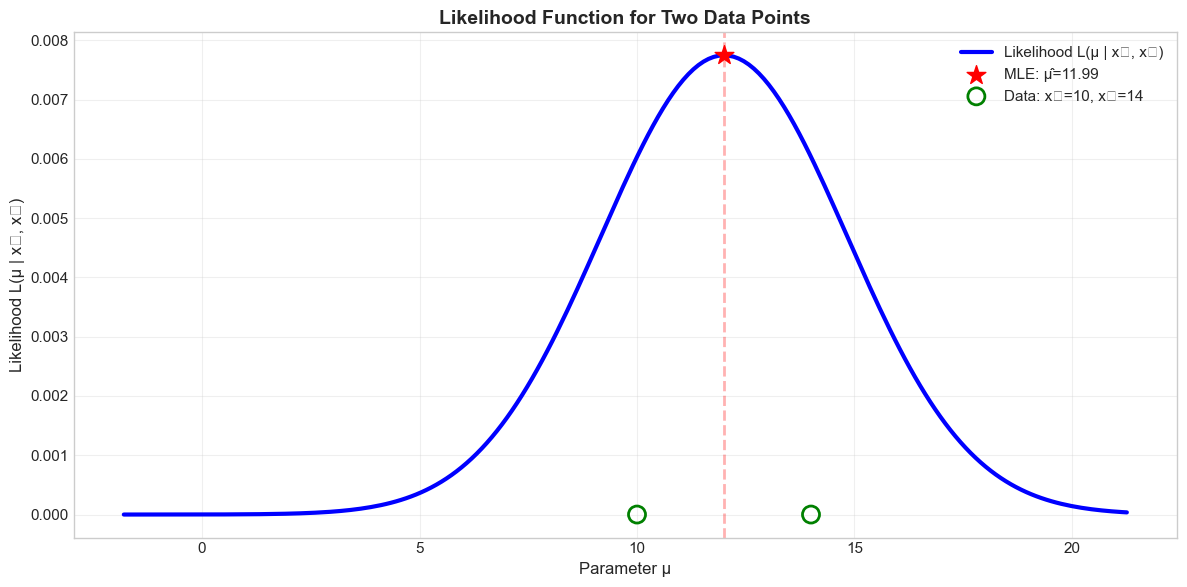

The MLE is μ̂=11.99, which is the average: (10+14)/2 = 12.0


In [14]:
x1 = 10
x2 = 14
std_dev = 4

# Vectorized computation for efficiency
L = normal_distribution(x1, mu_range, std_dev) * normal_distribution(x2, mu_range, std_dev)
max_index = L.argmax()
optimal_mean = mu_range[max_index]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(mu_range, L, 'b-', lw=3, label='Likelihood L(μ | x₁, x₂)')
ax.scatter(optimal_mean, L[max_index], color='red', s=200, zorder=5, 
           label=f'MLE: μ̂={optimal_mean:.2f}', marker='*')
ax.scatter([x1, x2], [0, 0], marker='o', s=150, facecolors='none', 
           edgecolors='green', linewidth=2, label=f'Data: x₁={x1}, x₂={x2}')
ax.axvline(optimal_mean, color='red', linestyle='--', alpha=0.3, lw=2)
ax.set_xlabel('Parameter μ', fontsize=12)
ax.set_ylabel('Likelihood L(μ | x₁, x₂)', fontsize=12)
ax.set_title('Likelihood Function for Two Data Points', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The MLE is μ̂={optimal_mean:.2f}, which is the average: ({x1}+{x2})/2 = {(x1+x2)/2}")

## 8. Likelihood of Three Data Points Given $\mu, \sigma$

$$\large  L(\mu,\sigma | x_1,x_2,x_3)= \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_1-\mu)^2}{2\sigma^2}\right) \times \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_2-\mu)^2}{2\sigma^2}\right) \times \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_3-\mu)^2}{2\sigma^2}\right)$$

Try what happens to the curve when you change the values of $\mu$ and $\sigma$ and the data point $x_1,x_2,x_3$

Assume that both the measures are independent

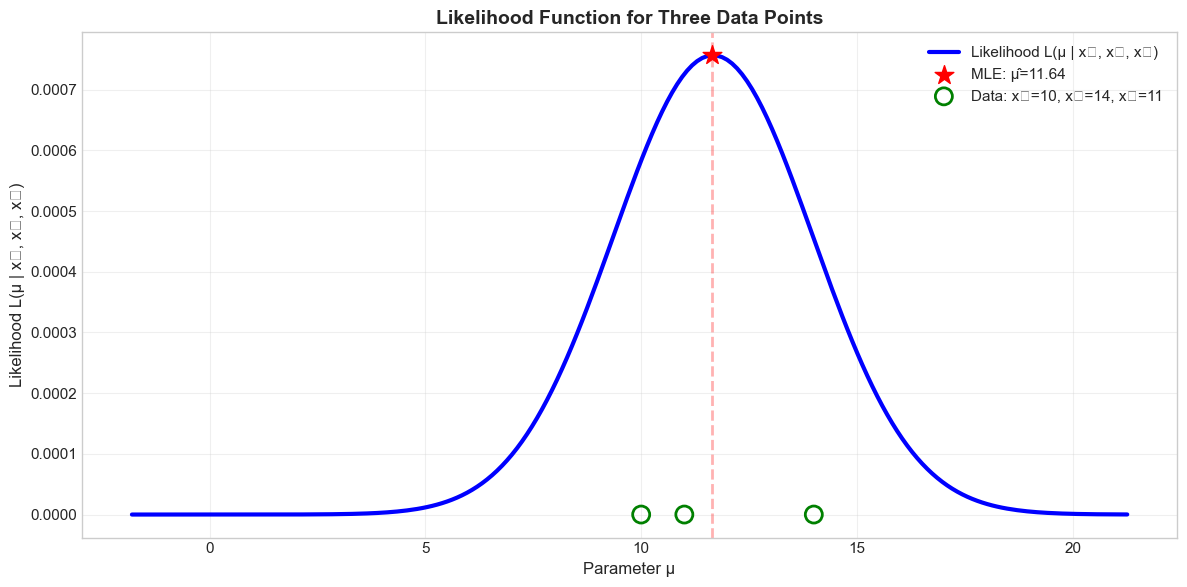

The MLE is μ̂=11.64, which is the average: (10+14+11)/3 = 11.67


In [15]:
x1 = 10
x2 = 14
x3 = 11
std_dev = 4

# Vectorized computation
L = (normal_distribution(x1, mu_range, std_dev) * 
     normal_distribution(x2, mu_range, std_dev) * 
     normal_distribution(x3, mu_range, std_dev))
max_index = L.argmax()
optimal_mean = mu_range[max_index]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(mu_range, L, 'b-', lw=3, label='Likelihood L(μ | x₁, x₂, x₃)')
ax.scatter(optimal_mean, L[max_index], color='red', s=200, zorder=5, 
           label=f'MLE: μ̂={optimal_mean:.2f}', marker='*')

ax.scatter([x1, x2, x3], [0, 0, 0], marker='o', s=150, facecolors='none', 
           edgecolors='green', linewidth=2, label=f'Data: x₁={x1}, x₂={x2}, x₃={x3}')
ax.axvline(optimal_mean, color='red', linestyle='--', alpha=0.3, lw=2)
ax.set_xlabel('Parameter μ', fontsize=12)
ax.set_ylabel('Likelihood L(μ | x₁, x₂, x₃)', fontsize=12)
ax.set_title('Likelihood Function for Three Data Points', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The MLE is μ̂={optimal_mean:.2f}, which is the average: ({x1}+{x2}+{x3})/3 = {(x1+x2+x3)/3:.2f}")

## 9. Likelihood of All Data Points Given $\mu, \sigma$

$L(\mu,\sigma | x_1,x_2,\cdots,x_n)$

$$\large  L(\mu,\sigma | x_1,x_2,\cdots,x_n)= \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)$$

For independent observations, the total likelihood is the **product** of individual likelihoods. As we add more data points, the likelihood function becomes more peaked around the true parameter value.

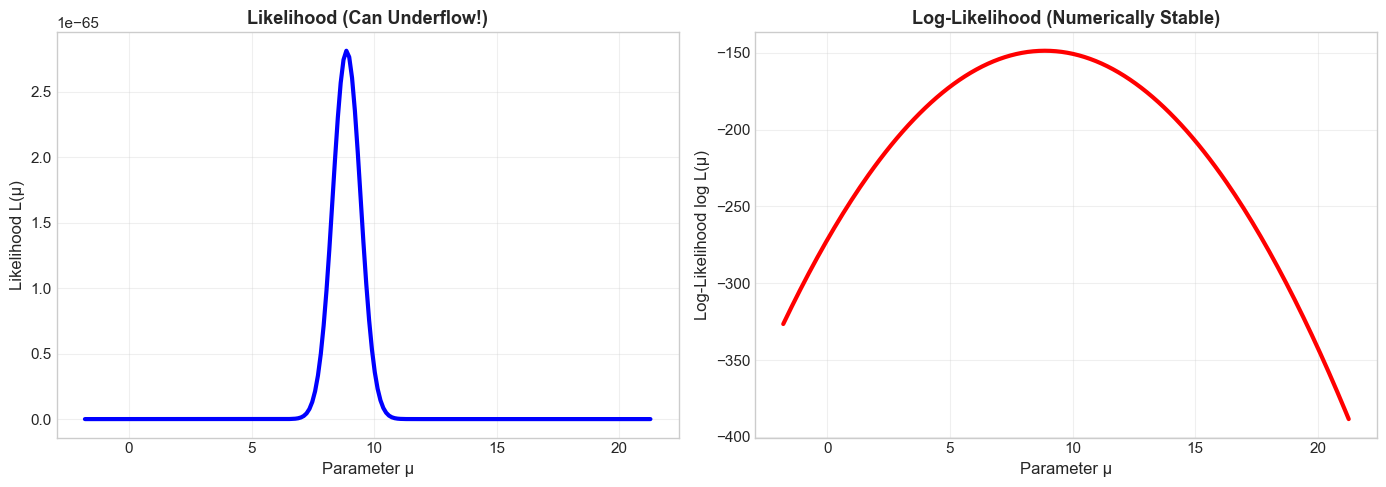

Likelihood value at MLE:     L = 1.74e-70 (Very small!)
Log-likelihood value at MLE: log L = -160.63 (Manageable)

✓ Both find the same maximum, but log-likelihood is numerically stable!


In [16]:
# Compute both likelihood and log-likelihood
L_mu = np.prod(normal_distribution(data[:, np.newaxis], mu_range, std_dev), axis=0)
logL_mu = np.sum(np.log(normal_distribution(data[:, np.newaxis], mu_range, std_dev)), axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Likelihood plot
ax1.plot(mu_range, L_mu, 'b-', lw=3)
ax1.set_xlabel('Parameter μ', fontsize=12)
ax1.set_ylabel('Likelihood L(μ)', fontsize=12)
ax1.set_title('Likelihood (Can Underflow!)', fontsize=13, fontweight='bold')
ax1.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax1.grid(True, alpha=0.3)

# Log-likelihood plot
ax2.plot(mu_range, logL_mu, 'r-', lw=3)
ax2.set_xlabel('Parameter μ', fontsize=12)
ax2.set_ylabel('Log-Likelihood log L(μ)', fontsize=12)
ax2.set_title('Log-Likelihood (Numerically Stable)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Likelihood value at MLE:     L = {L_mu[max_index]:.2e} (Very small!)")
print(f"Log-likelihood value at MLE: log L = {logL_mu[max_index]:.2f} (Manageable)")
print("\n✓ Both find the same maximum, but log-likelihood is numerically stable!")

## 12. Log-Likelihood Derivation

Let's derive the log-likelihood step-by-step:

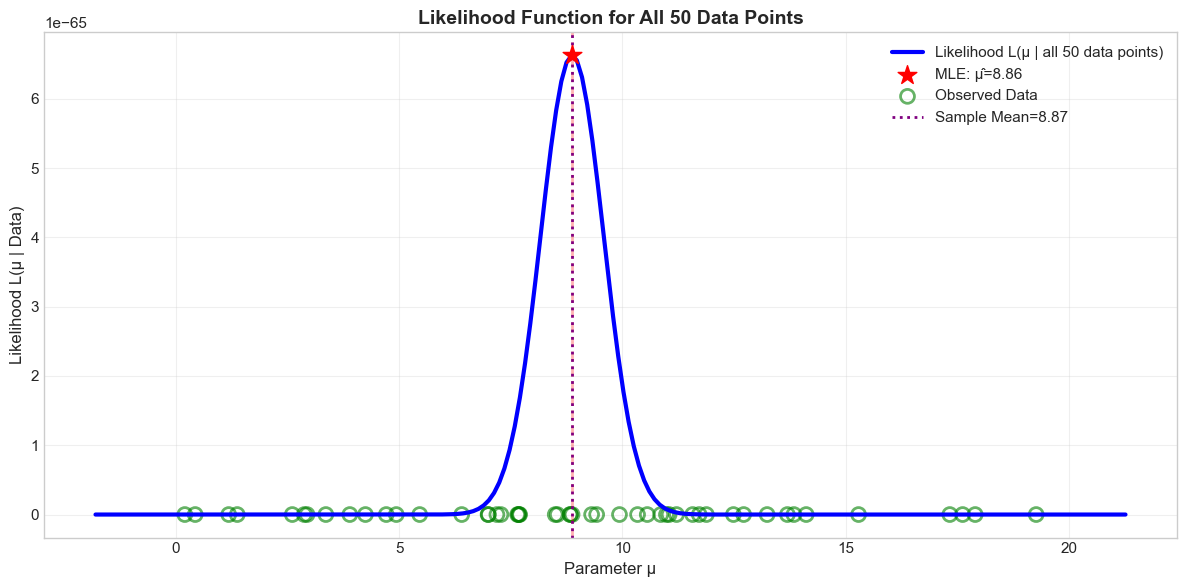

MLE estimate: μ̂ = 8.86
Sample mean:  x̄ = 8.87
True value:   μ = 10

✓ Notice: The MLE is extremely close to the sample mean!


In [17]:
std_dev = 5

# Efficient vectorized computation using broadcasting
L = np.prod(normal_distribution(data[:, np.newaxis], mu_range, std_dev), axis=0)
max_index = L.argmax()
optimal_mean = mu_range[max_index]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(mu_range, L, 'b-', lw=3, label=f'Likelihood L(μ | all {len(data)} data points)')
ax.scatter(optimal_mean, L[max_index], color='red', s=200, zorder=5, 
           label=f'MLE: μ̂={optimal_mean:.2f}', marker='*')

ax.scatter(data, np.zeros_like(data), marker='o', s=100, facecolors='none', 
           edgecolors='green', linewidth=2, label='Observed Data', alpha=0.6)
ax.axvline(optimal_mean, color='red', linestyle='--', alpha=0.3, lw=2)
ax.axvline(np.mean(data), color='purple', linestyle=':', lw=2, label=f'Sample Mean={np.mean(data):.2f}')
ax.set_xlabel('Parameter μ', fontsize=12)
ax.set_ylabel('Likelihood L(μ | Data)', fontsize=12)
ax.set_title(f'Likelihood Function for All {len(data)} Data Points', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"MLE estimate: μ̂ = {optimal_mean:.2f}")
print(f"Sample mean:  x̄ = {np.mean(data):.2f}")
print(f"True value:   μ = {true_mean}")
print("\n✓ Notice: The MLE is extremely close to the sample mean!")

## 10. Finding the Optimal Standard Deviation $\sigma$

Now that we have found the optimal value of the mean, let's find the optimal value of $\sigma$. We'll search over a range of $\sigma$ values while keeping $\mu$ fixed at its MLE.

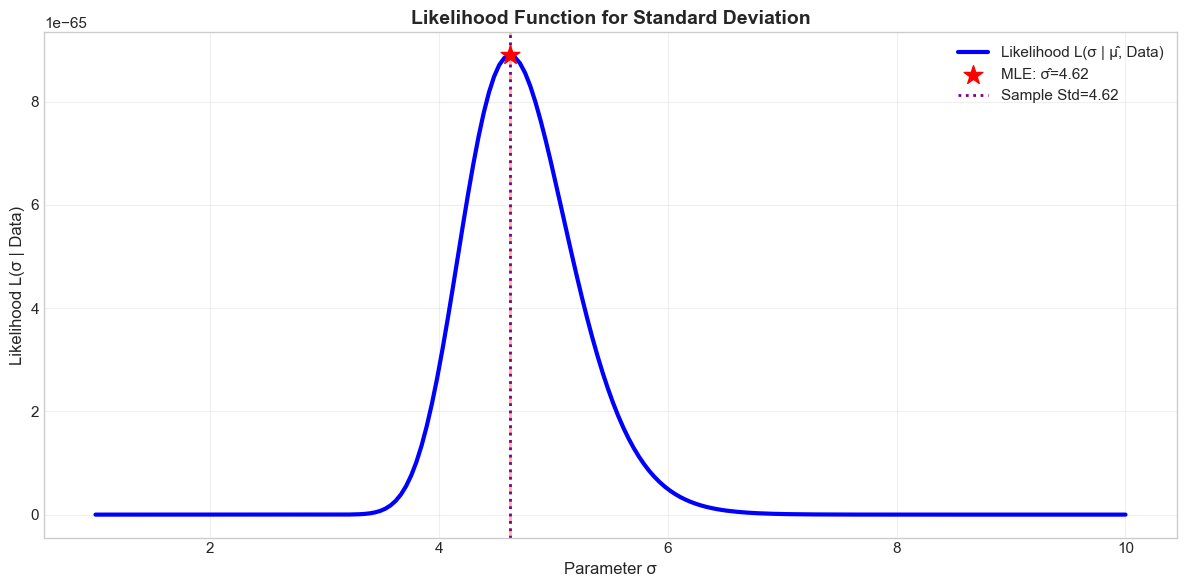

MLE estimate: σ̂ = 4.62
Sample std:   s = 4.62
True value:   σ = 5

✓ The MLE matches the sample standard deviation!


In [18]:
# Use the optimal mean from previous step
optimal_mean_fixed = mu_range[L.argmax()]

# Search over sigma range
sigma_range = np.linspace(1, 10, 200)

# Efficient vectorized computation
L_sigma = np.prod(normal_distribution(data[:, np.newaxis], optimal_mean_fixed, sigma_range), axis=0)
max_sigma_index = L_sigma.argmax()
optimal_sigma = sigma_range[max_sigma_index]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(sigma_range, L_sigma, 'b-', lw=3, label='Likelihood L(σ | μ̂, Data)')

ax.scatter(optimal_sigma, L_sigma[max_sigma_index], color='red', s=200, zorder=5, 
           label=f'MLE: σ̂={optimal_sigma:.2f}', marker='*')
ax.axvline(optimal_sigma, color='red', linestyle='--', alpha=0.3, lw=2)
ax.axvline(np.std(data), color='purple', linestyle=':', lw=2, label=f'Sample Std={np.std(data):.2f}')
ax.set_xlabel('Parameter σ', fontsize=12)
ax.set_ylabel('Likelihood L(σ | Data)', fontsize=12)
ax.set_title('Likelihood Function for Standard Deviation', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"MLE estimate: σ̂ = {optimal_sigma:.2f}")
print(f"Sample std:   s = {np.std(data):.2f}")
print(f"True value:   σ = {true_std_dev}")
print("\n✓ The MLE matches the sample standard deviation!")

## 11. Why Use Log-Likelihood?

Let's compare likelihood vs. log-likelihood:

When dealing with many data points, the likelihood (a product of many small probabilities) can become extremely small and cause **numerical underflow**. Taking the logarithm solves this problem:

- **Numerically stable**: Avoids underflow issues

- **Products become sums**: $\log(a \times b) = \log(a) + \log(b)$- **Monotonic transformation**: $\argmax L(\theta) = \argmax \log L(\theta)$

$$\large  L(\mu,\sigma | x_1,x_2,\cdots,x_n)= \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_1-\mu)^2}{2\sigma^2}\right) \times \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_2-\mu)^2}{2\sigma^2}\right)\times \cdots \times \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_n-\mu)^2}{2\sigma^2}\right)$$

$$log(\large  L(\mu,\sigma | x_1,x_2,\cdots,x_n))= log \left[ \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_1-\mu)^2}{2\sigma^2}\right) \times \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_2-\mu)^2}{2\sigma^2}\right)\times \cdots \times \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_n-\mu)^2}{2\sigma^2}\right) \right]$$

$$log(\large  L(\mu,\sigma | x_1,x_2,\cdots,x_n))= n log \left\{ \left( \frac{1}{\sqrt{2\pi\sigma^2}} \right)    \left[ exp\left(-\frac{(x_1-\mu)^2}{2\sigma^2}\right) \times  \exp\left(-\frac{(x_2-\mu)^2}{2\sigma^2}\right)\times \cdots \times \exp\left(-\frac{(x_n-\mu)^2}{2\sigma^2}\right) \right] \right\}$$

$$log(\large  L(\mu,\sigma | x_1,x_2,\cdots,x_n))= -\frac{n}{2} log  \left(2\pi\sigma^2 \right)  +log \left\{  \left[ exp\left(-\frac{(x_1-\mu)^2}{2\sigma^2}\right) \times  \exp\left(-\frac{(x_2-\mu)^2}{2\sigma^2}\right)\times \cdots \times \exp\left(-\frac{(x_n-\mu)^2}{2\sigma^2}\right) \right] \right\}$$

$$log(\large  L(\mu,\sigma | x_1,x_2,\cdots,x_n))= -\frac{n}{2} log  \left(2\pi\sigma^2 \right)  +log \left\{   exp\left(-\frac{(x_1-\mu)^2}{2\sigma^2}\right) \right\} +  log \left\{\exp\left(-\frac{(x_2-\mu)^2}{2\sigma^2}\right) \right\} + \cdots +  log \left\{\exp\left(-\frac{(x_n-\mu)^2}{2\sigma^2}\right) \right\}$$

$$log(\large  L(\mu,\sigma | x_1,x_2,\cdots,x_n))= -\frac{n}{2} log  \left(2\pi\sigma^2 \right)  -\frac{(x_1-\mu)^2}{2\sigma^2} -\frac{(x_2-\mu)^2}{2\sigma^2} + \cdots -\frac{(x_n-\mu)^2}{2\sigma^2}$$

## 15. Confidence Intervals

MLE theory tells us that for large samples, the MLE is approximately normally distributed:

$$\hat{\mu} \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)$$

This allows us to construct confidence intervals:


CONFIDENCE INTERVALS

Sample size: n = 50
Estimated μ̂ = 8.8726
Estimated σ̂ = 4.6683
Standard Error of Mean = σ̂/√n = 0.6602

95% Confidence Interval for μ:
  [7.5459, 10.1994]

Interpretation: We are 95% confident that the true
mean μ lies between 7.55 and 10.20.

✓ The true mean (μ=10) IS within our confidence interval!


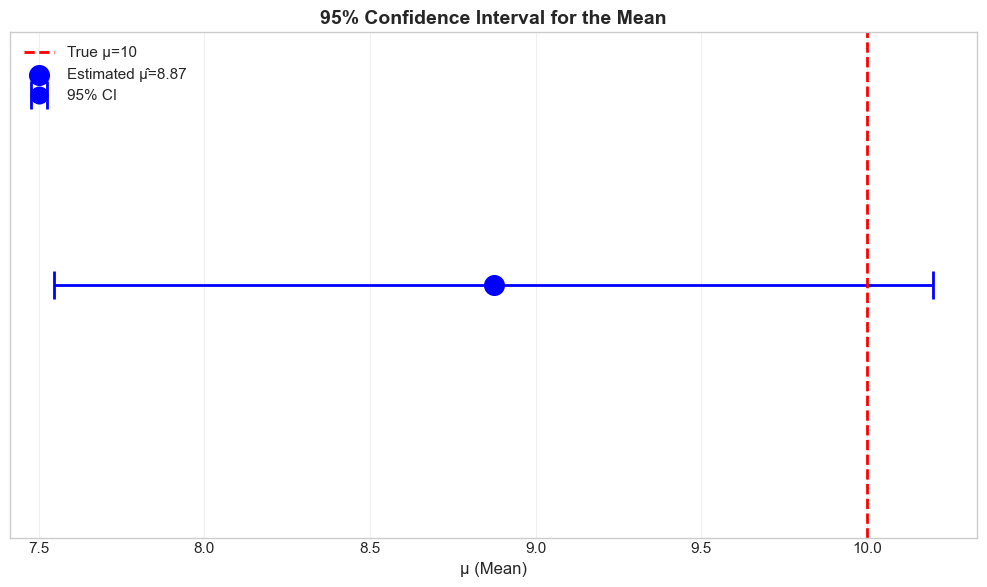

In [19]:
from scipy import stats

# Sample statistics
mean_est = np.mean(data)
std_est = np.std(data, ddof=1)  # Use unbiased estimator for CI
n = len(data)

# Standard error of the mean
se_mean = std_est / np.sqrt(n)

# 95% Confidence Interval for the mean
confidence_level = 0.95
alpha = 1 - confidence_level
t_critical = stats.t.ppf(1 - alpha/2, df=n-1)  # t-distribution for small samples

ci_lower = mean_est - t_critical * se_mean
ci_upper = mean_est + t_critical * se_mean

print("\n" + "="*60)
print("CONFIDENCE INTERVALS")
print("="*60)
print(f"\nSample size: n = {n}")
print(f"Estimated μ̂ = {mean_est:.4f}")
print(f"Estimated σ̂ = {std_est:.4f}")
print(f"Standard Error of Mean = σ̂/√n = {se_mean:.4f}")
print(f"\n{confidence_level*100:.0f}% Confidence Interval for μ:")
print(f"  [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\nInterpretation: We are {confidence_level*100:.0f}% confident that the true")
print(f"mean μ lies between {ci_lower:.2f} and {ci_upper:.2f}.")

# Check if true mean is in CI
if ci_lower <= true_mean <= ci_upper:
    print(f"\n✓ The true mean (μ={true_mean}) IS within our confidence interval!")
else:
    print(f"\n✗ The true mean (μ={true_mean}) is NOT within our confidence interval.")
    print("  (This happens ~5% of the time for 95% CI)")
print("="*60)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(mean_est, 0, xerr=[[mean_est-ci_lower], [ci_upper-mean_est]], 
            fmt='o', markersize=12, capsize=10, capthick=2, linewidth=2, 
            color='blue', label=f'{confidence_level*100:.0f}% CI')
ax.axvline(true_mean, color='red', linestyle='--', linewidth=2, label=f'True μ={true_mean}')
ax.scatter(mean_est, 0, s=200, c='blue', zorder=5, label=f'Estimated μ̂={mean_est:.2f}')
ax.set_xlabel('μ (Mean)', fontsize=12)
ax.set_yticks([])
ax.set_title(f'{confidence_level*100:.0f}% Confidence Interval for the Mean', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 16. Summary & Key Takeaways

### What We Learned:

1. **The Normal Distribution** is characterized by two parameters: mean ($\mu$) and standard deviation ($\sigma$).

2. **Likelihood** measures how probable the observed data is under different parameter values.

3. **Maximum Likelihood Estimation (MLE)** finds the parameter values that maximize the likelihood of observing the data.

4. **For the Normal distribution:**
   - MLE for $\mu$ = Sample mean: $\hat{\mu} = \bar{x}$
   - MLE for $\sigma^2$ = Biased sample variance: $\hat{\sigma}^2 = \frac{1}{n}\sum(x_i-\bar{x})^2$

5. **Log-Likelihood** is preferred in practice because:
   - Products become sums
   - Numerically stable (avoids underflow)
   - Same maximum as likelihood

6. **Three ways to find MLE:**
   - Grid search (visual but inefficient)
   - Numerical optimization (scipy.optimize.minimize)
   - Analytical solution (calculus, when possible)

7. **Confidence intervals** quantify uncertainty in our estimates.

### Important Notes:

- MLE is **consistent**: As $n \to \infty$, $\hat{\theta} \to \theta$
- MLE is **asymptotically normal**: For large $n$, $\hat{\theta} \sim \mathcal{N}(\theta, \text{SE}^2)$
- MLE is **asymptotically efficient**: Has the smallest variance among consistent estimators
- MLE can be **biased** for small samples (e.g., $\hat{\sigma}^2$)

### Next Steps:

- Try with different distributions (Exponential, Poisson, etc.)
- Explore what happens with outliers
- Learn about Bayesian estimation as an alternative to MLE
- Study regularization (Ridge, Lasso) as modified MLE

---

**Congratulations! You now understand Maximum Likelihood Estimation for the Normal distribution!** 🎉

$$log(\large  L(\mu,\sigma | x_1,x_2,\cdots,x_n))= - \left\{ \frac{n}{2} log  \left(2\pi\sigma^2 \right)  +  \frac{1}{2\sigma^2}  [ (x_1-\mu)^2 +(x_2-\mu)^2 + \cdots +(x_n-\mu)^2] \right\}$$

$$log(\large  L(\mu,\sigma | x_1,x_2,\cdots,x_n))= - \left\{ \frac{n}{2} log  \left(2\pi \right) + n log(\sigma)   +  \frac{1}{2\sigma^2}  [ (x_1-\mu)^2 +(x_2-\mu)^2 + \cdots +(x_n-\mu)^2] \right\}$$

## 13. Numerical Optimization with SciPy

Instead of searching over a grid, we can use numerical optimization to find the MLE directly. We minimize the **negative log-likelihood** (equivalently, maximize log-likelihood).

In [20]:
def neg_log_likelihood(parameters, X):
    """
    Negative log-likelihood for Normal distribution.
    We minimize this to find the MLE.
    """
    mu = parameters[0]
    sigma = parameters[1]
    
    # Prevent sigma from being negative or zero
    if sigma <= 0:
        return np.inf
    
    n = len(X)
    nll = (n/2 * np.log(2 * np.pi) + 
           n/2 * np.log(sigma ** 2) + 
           1/(2 * sigma ** 2) * np.sum((X - mu) ** 2))
    return nll

# Initial guess
initial_params = [8, 3]

# Optimize
result = minimize(neg_log_likelihood, initial_params, args=(data,), 
                  method='L-BFGS-B', bounds=[(None, None), (0.01, None)])

print("\n" + "="*60)
print("NUMERICAL OPTIMIZATION RESULTS (SciPy)")
print("="*60)
print(f"Estimated μ (mean):      {result.x[0]:.4f}")
print(f"Estimated σ (std dev):   {result.x[1]:.4f}")
print(f"Maximum log-likelihood:  {-result.fun:.4f}")
print(f"Optimization success:    {result.success}")
print("\nComparison with Sample Statistics:")
print(f"Sample mean:             {np.mean(data):.4f}")
print(f"Sample std (biased):     {np.std(data, ddof=0):.4f}")
print(f"Sample std (unbiased):   {np.std(data, ddof=1):.4f}")
print(f"\nTrue parameters: μ={true_mean}, σ={true_std_dev}")
print("="*60)


NUMERICAL OPTIMIZATION RESULTS (SciPy)
Estimated μ (mean):      8.8726
Estimated σ (std dev):   4.6214
Maximum log-likelihood:  -147.4821
Optimization success:    True

Comparison with Sample Statistics:
Sample mean:             8.8726
Sample std (biased):     4.6214
Sample std (unbiased):   4.6683

True parameters: μ=10, σ=5


## 14. Analytical Solution (Closed-Form MLE)

For the Normal distribution, we can derive the MLE analytically by taking derivatives and setting them to zero.

### For $\mu$ (Mean):

$ \large \dfrac{\partial }{\partial \mu}\log\mathcal{L}(\mu,\sigma | x_1,x_2,\cdots,x_n)=\dfrac{1}{2\sigma^2} \left[ 2(x_1-\mu) + 2(x_2-\mu) +\cdots 2(x_n-\mu)\right] = \dfrac{1}{\sigma^2}(x_1+x_2+\cdots+x_n -n\mu)=0$

Solving for $\mu$:

**Result: The MLE for $\sigma^2$ is the biased sample variance (divide by $n$, not $n-1$).**

$$\large \boxed{\hat{\mu}_{\text{MLE}}=\dfrac{x_1+x_2+\cdots+x_n}{n} =\dfrac{1}{n}\sum_{i=1}^n x_i = \bar{x}}$$

$$\large \boxed{\hat{\sigma}^2_{\text{MLE}}=\dfrac{1}{n}\sum_{i=1}^n (x_i-\bar{x})^2}$$

**Result: The MLE for $\mu$ is the sample mean!**

Solving for $\sigma^2$:

### For $\sigma$ (Standard Deviation):

$\large \dfrac{\partial }{\partial \sigma}\log L(\mu,\sigma | x_1,x_2,\cdots,x_n)=-\dfrac{n}{\sigma}-\frac{1}{\sigma^3}[ (x_1-\mu)^2 +(x_2-\mu)^2 + \cdots +(x_n-\mu)^2]=0$

In [21]:
print("\n" + "="*60)
print("ANALYTICAL MLE FORMULAS")
print("="*60)
print(f"\nMLE for μ:  μ̂ = (1/n)Σxᵢ = {np.mean(data):.4f}")
print(f"MLE for σ²: σ̂² = (1/n)Σ(xᵢ-μ̂)² = {np.var(data, ddof=0):.4f}")
print(f"MLE for σ:  σ̂ = √(σ̂²) = {np.std(data, ddof=0):.4f}")

print("\n" + "-"*60)
print("Comparison with different estimators:")
print("-"*60)
print(f"Sample mean (MLE):              {np.mean(data):.4f}")
print(f"Sample variance (MLE, biased):  {np.var(data, ddof=0):.4f}  [divides by n]")
print(f"Sample variance (unbiased):     {np.var(data, ddof=1):.4f}  [divides by n-1]")
print(f"Sample std (MLE, biased):       {np.std(data, ddof=0):.4f}")
print(f"Sample std (unbiased):          {np.std(data, ddof=1):.4f}")

print("\n" + "-"*60)
print(f"True parameters: μ={true_mean}, σ={true_std_dev}")
print("="*60)

print("\n📝 Note: The MLE for variance is biased (underestimates on average).")
print("   That's why statisticians often use the unbiased estimator (n-1).")


ANALYTICAL MLE FORMULAS

MLE for μ:  μ̂ = (1/n)Σxᵢ = 8.8726
MLE for σ²: σ̂² = (1/n)Σ(xᵢ-μ̂)² = 21.3576
MLE for σ:  σ̂ = √(σ̂²) = 4.6214

------------------------------------------------------------
Comparison with different estimators:
------------------------------------------------------------
Sample mean (MLE):              8.8726
Sample variance (MLE, biased):  21.3576  [divides by n]
Sample variance (unbiased):     21.7934  [divides by n-1]
Sample std (MLE, biased):       4.6214
Sample std (unbiased):          4.6683

------------------------------------------------------------
True parameters: μ=10, σ=5

📝 Note: The MLE for variance is biased (underestimates on average).
   That's why statisticians often use the unbiased estimator (n-1).
